## Load Mel Paths and Basic Setup

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from multiprocessing import Pool
import random

mel_root = "/work/NLP-mini-project/datasets/fma/fma_clean/mels/"

# Collect mel file paths
mel_paths = []

for root, dirs, files in os.walk(mel_root):
    for f in files:
        if f.endswith(".npy"):
            mel_paths.append(os.path.join(root, f))

print("Found mel files:", len(mel_paths))

# Function to load shape only
def load_shape(path):
    mel = np.load(path, mmap_mode='r')   # zero-copy memory mapping
    return mel.shape

# Parallel load shapes
with Pool(processes=32) as p:
    mel_shapes = list(p.map(load_shape, mel_paths))

mel_shapes = np.array(mel_shapes)
time_lengths = mel_shapes[:, 1]
freq_bins = mel_shapes[:, 0]

print("Done. Shapes loaded.")

Found mel files: 90086
Done. Shapes loaded.


## Plot Random Mel Spectrograms for Visual Inspection

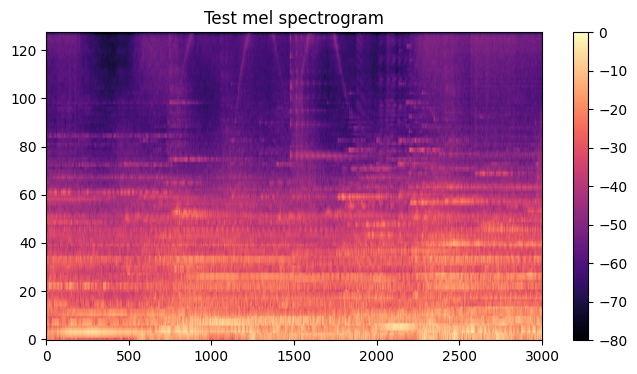

In [3]:
mel = np.load(random.choice(mel_paths))
plt.figure(figsize=(8,4))
plt.imshow(mel, aspect="auto", origin="lower", cmap="magma")
plt.colorbar()
plt.title("Test mel spectrogram")
plt.show()

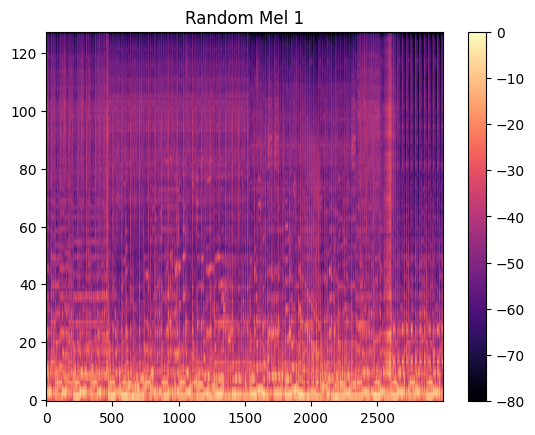

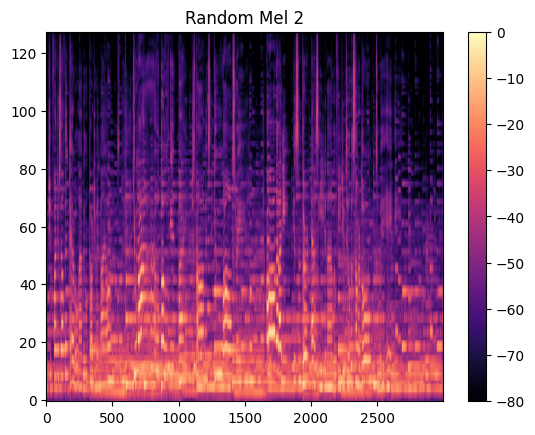

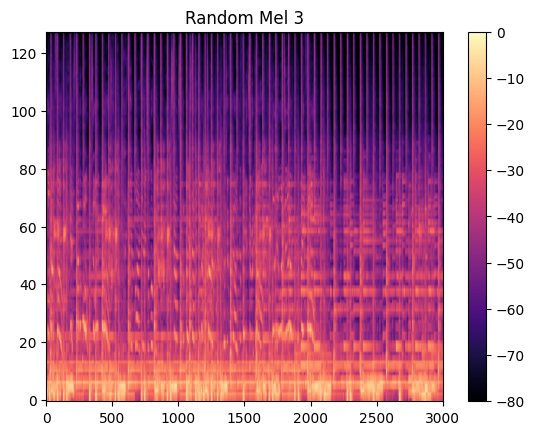

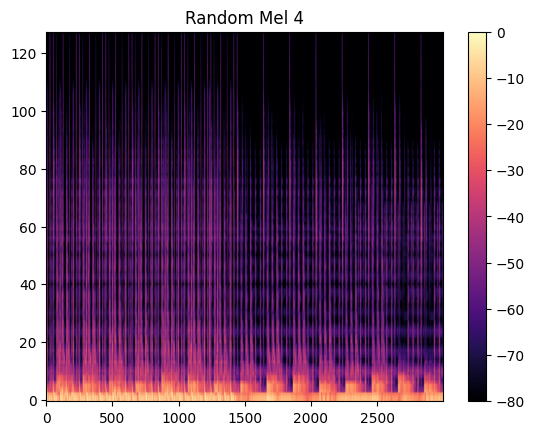

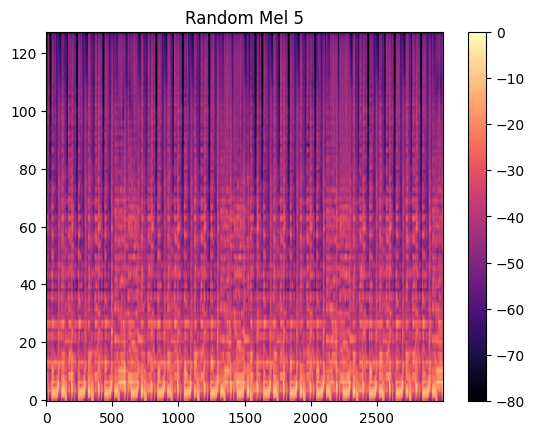

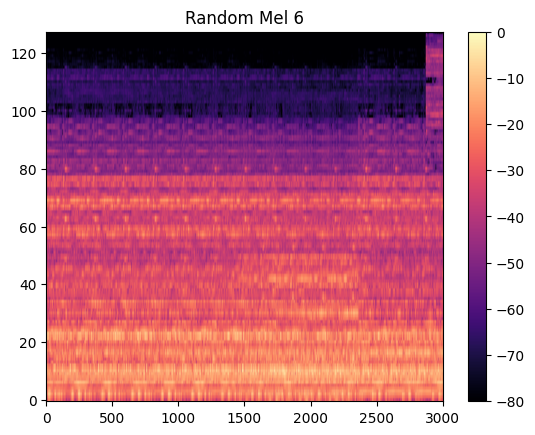

In [4]:
# Visualize random mel spectrograms to inspect quality

for i in range(6):
    mel = np.load(random.choice(mel_paths))
    plt.imshow(mel, aspect='auto', origin='lower', cmap='magma')
    plt.title("Random Mel {}".format(i+1))
    plt.colorbar()
    plt.show()

## Inspect Value Range Of Random Mel

In [5]:
mel = np.load(random.choice(mel_paths))
print("Shape:", mel.shape)
print("Min:", mel.min())
print("Max:", mel.max())
print("Mean:", mel.mean())
print("Std:", mel.std())

Shape: (128, 3001)
Min: -80.0
Max: 0.0
Mean: -41.156757
Std: 18.86759


## Verify distribution across many samples

In [6]:
mins = []
maxs = []
means = []

for p in random.sample(mel_paths, 500):
    mel = np.load(p)
    mins.append(mel.min())
    maxs.append(mel.max())
    means.append(mel.mean())

print("Min(dB) stats: min =", min(mins), "max =", max(mins), "mean =", np.mean(mins))
print("Max(dB) stats: min =", min(maxs), "max =", max(maxs), "mean =", np.mean(maxs))
print("Mean(dB) stats: min =", min(means), "max =", max(means), "mean =", np.mean(means))

Min(dB) stats: min = -80.0 max = -78.99253 mean = -79.997696
Max(dB) stats: min = 0.0 max = 0.0 mean = 0.0
Mean(dB) stats: min = -68.84057 max = -25.816 mean = -46.676743


## Inspect histogram of values (should match dB scale)

Long tail around -80 dB

Peak around -20 to -30 dB

Sharp cutoff near 0 dB

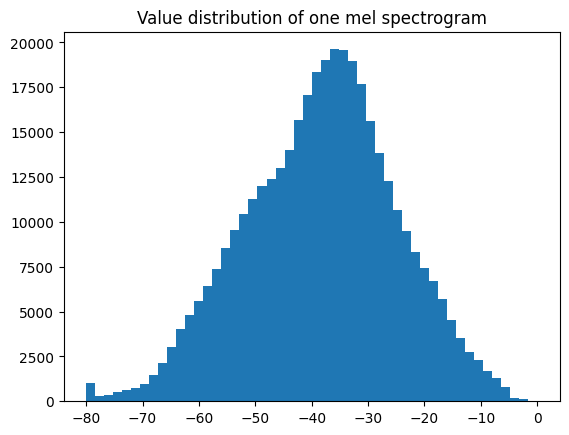

In [7]:
mel = np.load(random.choice(mel_paths))
plt.hist(mel.flatten(), bins=50)
plt.title("Value distribution of one mel spectrogram")
plt.show()

## Compute Mel Shapes (Frames + Frequency Bins)

In [8]:
from multiprocessing import Pool

# Function to load only the shape of each mel file
def load_shape(path):
    mel = np.load(path, mmap_mode='r')  # mmap avoids full load to RAM
    return mel.shape

# Parallel processing of mel shapes
with Pool(processes=32) as p:   # adjust to available CPUs
    mel_shapes = p.map(load_shape, mel_paths)

mel_shapes = np.array(mel_shapes)

time_lengths = mel_shapes[:, 1]
freq_bins = mel_shapes[:, 0]

print("Unique frequency bin counts:", np.unique(freq_bins))
print("Time frame stats:")
print("Min:", time_lengths.min())
print("Max:", time_lengths.max())
print("Mean:", time_lengths.mean())
print("Std:", time_lengths.std())


Unique frequency bin counts: [128]
Time frame stats:
Min: 2952
Max: 3047
Mean: 2999.3012343760406
Std: 1.5941345751905496


## List All Time-Frame Lengths and Their Counts

In [9]:
from collections import Counter

length_counts = Counter(time_lengths)

print("Frame length  ->  count")
print("--------------------------------")

for length in sorted(length_counts):
    print(f"{length:5d}        ->  {length_counts[length]}")

Frame length  ->  count
--------------------------------
 2952        ->  1
 2955        ->  2
 2958        ->  1
 2963        ->  1
 2966        ->  1
 2971        ->  1
 2973        ->  1
 2975        ->  1
 2978        ->  1
 2983        ->  1
 2984        ->  1
 2993        ->  1
 2995        ->  5
 2996        ->  6
 2997        ->  261
 2998        ->  48248
 2999        ->  3635
 3000        ->  174
 3001        ->  37712
 3002        ->  1
 3003        ->  2
 3005        ->  3
 3006        ->  2
 3007        ->  2
 3008        ->  2
 3015        ->  1
 3018        ->  1
 3019        ->  1
 3020        ->  1
 3023        ->  2
 3024        ->  1
 3026        ->  1
 3032        ->  1
 3033        ->  2
 3036        ->  1
 3038        ->  1
 3039        ->  1
 3040        ->  1
 3041        ->  3
 3042        ->  1
 3047        ->  1


## Plot Distribution of Mel Time Lengths

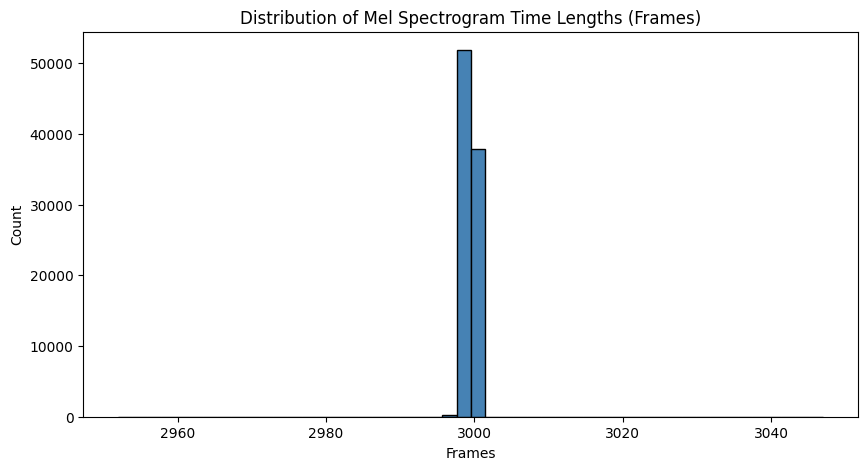

In [10]:
# Histogram of time lengths of mel spectrograms
plt.figure(figsize=(10, 5))
plt.hist(time_lengths, bins=50, color="steelblue", edgecolor="black")
plt.title("Distribution of Mel Spectrogram Time Lengths (Frames)")
plt.xlabel("Frames")
plt.ylabel("Count")
plt.show()

## Compute Global Mean and Standard Deviation of All Mels

In [11]:
# Compute global mean and std by reading all mels
# Useful for normalization during model training
import random
from multiprocessing import Pool

# Sample only N mel files (tune for speed)
N = 2000
sample_paths = random.sample(mel_paths, N)

def compute_stats(path):
    mel = np.load(path, mmap_mode='r')
    return mel.mean(), mel.std()

with Pool(processes=32) as p:
    stats = p.map(compute_stats, sample_paths)

means = np.array([s[0] for s in stats])
stds  = np.array([s[1] for s in stats])

print("Global mean (sample):", means.mean())
print("Global std  (sample):", stds.mean())


Global mean (sample): -46.522694
Global std  (sample): 16.067831


## Detect Potential Outlier Mels (Very Quiet or Empty)

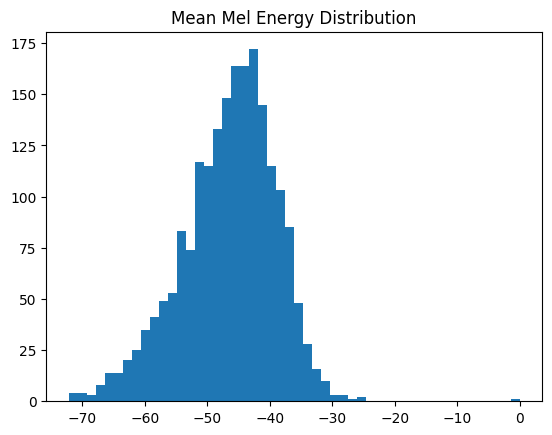

Possibly silent mels: 20


In [12]:
# Identify mels that have very low energy, possibly silent or corrupted

def compute_energy(path):
    mel = np.load(path, mmap_mode='r')
    return mel.mean()

with Pool(processes=32) as p:
    energies = p.map(compute_energy, sample_paths)  # sample 2k

energies = np.array(energies)

plt.hist(energies, bins=50)
plt.title("Mean Mel Energy Distribution")
plt.show()

threshold = np.percentile(energies, 1)
print("Possibly silent mels:", np.sum(energies < threshold))


## PCA on Flattened Mel Spectrograms (Structure Exploration)

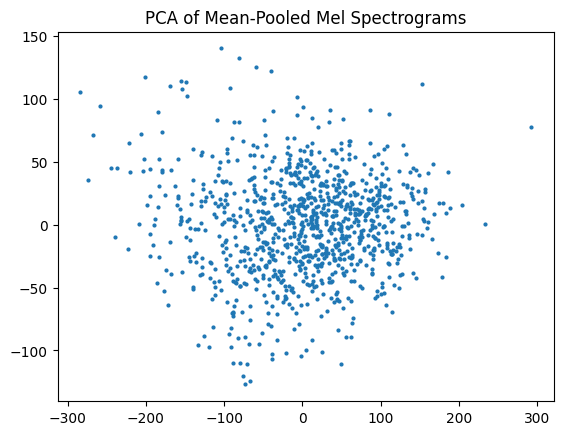

In [13]:
# PCA visualization to detect structure in mel embeddings

from sklearn.decomposition import PCA

K = 1000
sample_paths = random.sample(mel_paths, K)

X = []
for path in sample_paths:
    mel = np.load(path, mmap_mode='r')
    X.append(mel.mean(axis=1))

X = np.vstack(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], s=4)
plt.title("PCA of Mean-Pooled Mel Spectrograms")
plt.show()


In [19]:
import pandas as pd

# CHANGE THIS to the actual path where your cleaned metadata is stored
metadata_path = "/work/NLP-mini-project/datasets/fma/fma_clean/clean_metadata.csv"

metadata = pd.read_csv(metadata_path)

print("Loaded metadata:", metadata.shape)
metadata.head()


Loaded metadata: (90086, 17)


,track_id,audio_path,top_genres,num_labels,label_Rock,label_Electronic,label_Pop,label_Folk,label_Instrumental,label_HipHop,label_International,label_Classical,label_Jazz,label_Country,label_Blues,label_SoulRnB,mel_path
0,2,/datasets/fma/fma_clean/fma_selected/000/00000...,[21],1,0,0,0,0,0,1,0,0,0,0,0,0,/work/NLP-mini-project/datasets/fma/fma_clean/...
1,3,/datasets/fma/fma_clean/fma_selected/000/00000...,[21],1,0,0,0,0,0,1,0,0,0,0,0,0,/work/NLP-mini-project/datasets/fma/fma_clean/...
2,5,/datasets/fma/fma_clean/fma_selected/000/00000...,[21],1,0,0,0,0,0,1,0,0,0,0,0,0,/work/NLP-mini-project/datasets/fma/fma_clean/...
3,10,/datasets/fma/fma_clean/fma_selected/000/00001...,[10],1,0,0,1,0,0,0,0,0,0,0,0,0,/work/NLP-mini-project/datasets/fma/fma_clean/...
4,20,/datasets/fma/fma_clean/fma_selected/000/00002...,"[17, 10]",2,0,0,1,1,0,0,0,0,0,0,0,0,/work/NLP-mini-project/datasets/fma/fma_clean/...


In [20]:
## Genre-wise Mean Mel-Frequency Profiles (Weighted Averaging)

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# 1. Define selected genres
selected_genres = [
    "Rock", "Electronic", "Pop", "Folk", "Instrumental", "HipHop",
    "International", "Classical", "Jazz", "Country", "Blues", "SoulRnB"
]

# 2. Pre-build track_id -> mel_path mapping from metadata
trackid_to_melpath = {
    int(row.track_id): row.mel_path
    for _, row in metadata.iterrows()
    if isinstance(row.mel_path, str)
}

# 3. Prepare accumulators
genre_sums = {g: np.zeros(128) for g in selected_genres}
genre_weights = {g: 0.0 for g in selected_genres}

# 4. Loop over metadata rows and accumulate weighted profiles
for _, row in metadata.iterrows():

    track_id = int(row.track_id)

    # Skip if mel not found
    if track_id not in trackid_to_melpath:
        continue

    mel_path = trackid_to_melpath[track_id]
    if not isinstance(mel_path, str):
        continue

    # Extract list of genres for this track
    genres = []
    for g in selected_genres:
        col = f"label_{g}"
        if row[col] == 1:
            genres.append(g)

    # Skip tracks with no valid labels
    if len(genres) == 0:
        continue

    # Load mel
    mel = np.load(mel_path, mmap_mode='r')

    # Frequency profile = mean over time
    freq_profile = mel.mean(axis=1)

    # Weight = 1 / number of genres
    w = 1 / len(genres)

    # Add weighted contribution
    for g in genres:
        genre_sums[g] += w * freq_profile
        genre_weights[g] += w

# 5. Normalize
genre_profiles = {
    g: genre_sums[g] / max(genre_weights[g], 1e-8)
    for g in selected_genres
}

print("Finished computing genre-wise frequency profiles.")


Finished computing genre-wise frequency profiles.


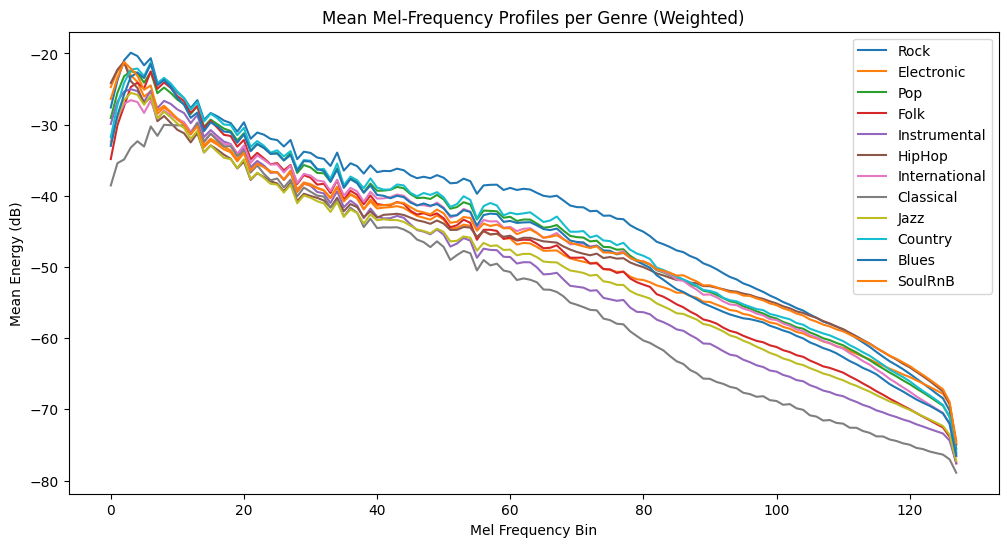

In [21]:
## Plot mean Mel-frequency profiles for all genres

plt.figure(figsize=(12, 6))

for g in selected_genres:
    plt.plot(genre_profiles[g], label=g)

plt.title("Mean Mel-Frequency Profiles per Genre (Weighted)")
plt.xlabel("Mel Frequency Bin")
plt.ylabel("Mean Energy (dB)")
plt.legend()
plt.show()


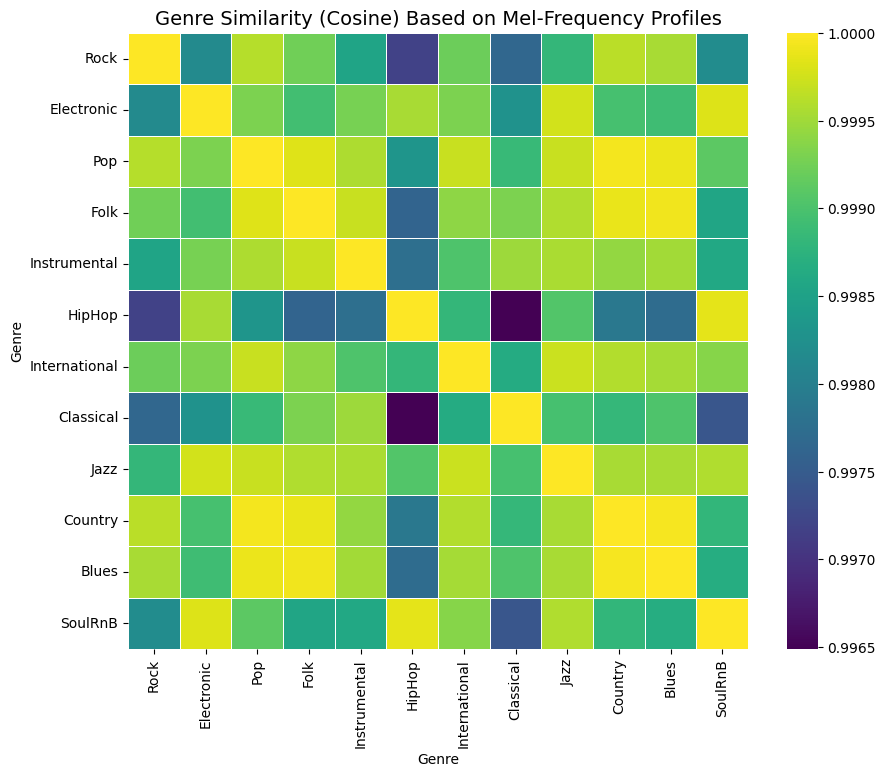

In [22]:
## Cosine Similarity Between Genre Profiles
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare matrix of shape (12, 128)
genres = selected_genres
profile_matrix = np.vstack([genre_profiles[g] for g in genres])  # (12 × 128)

# Normalize each profile for cosine similarity
norms = np.linalg.norm(profile_matrix, axis=1, keepdims=True)
normalized = profile_matrix / norms

# Cosine similarity = dot product of normalized rows
similarity_matrix = np.dot(normalized, normalized.T)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=False, xticklabels=genres, yticklabels=genres,
            cmap="viridis", linewidths=0.5)
plt.title("Genre Similarity (Cosine) Based on Mel-Frequency Profiles", fontsize=14)
plt.xlabel("Genre")
plt.ylabel("Genre")
plt.show()


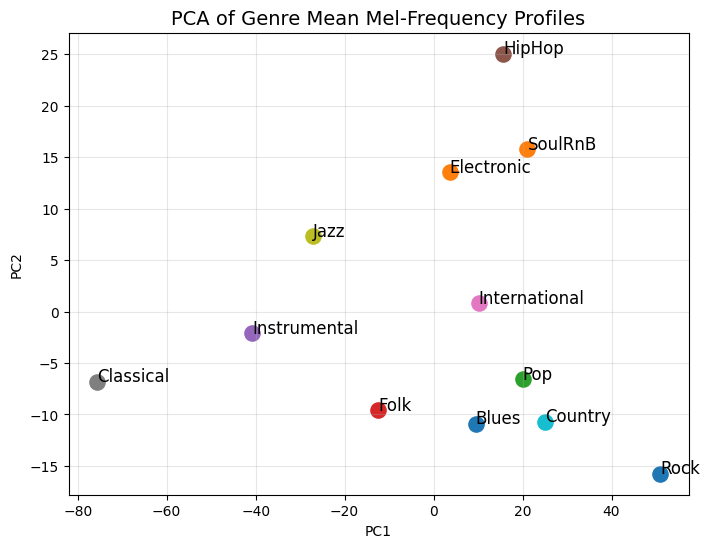

In [23]:
## PCA on Genre Profiles
from sklearn.decomposition import PCA

# Prepare data
genres = selected_genres
profile_matrix = np.vstack([genre_profiles[g] for g in genres])  # (12 × 128)

# Fit PCA
pca = PCA(n_components=2)
profiles_2d = pca.fit_transform(profile_matrix)

# Plot
plt.figure(figsize=(8, 6))
for i, g in enumerate(genres):
    x, y = profiles_2d[i]
    plt.scatter(x, y, s=120)
    plt.text(x + 0.01, y + 0.01, g, fontsize=12)

plt.title("PCA of Genre Mean Mel-Frequency Profiles", fontsize=14)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()
